<a href="https://colab.research.google.com/github/freddy-7/TI3002C/blob/main/5_Extracci%C3%B3n_de_Caracter%C3%ADsticas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
#Importamos las librerias pandas, numpy y matplotlib respectivamente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.options.display.max_rows=None

In [56]:
#Carga desde un archivo .xlsx sin indice
Micro_Retailer= pd.read_csv('ventasNegadasCRM_SIN_NULOS.csv') 

In [57]:
#Verificamos información del DataFrame
Micro_Retailer.info()

<class 'pandas.DataFrame'>
RangeIndex: 5268 entries, 0 to 5267
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Unnamed: 0             5268 non-null   int64
 1   id_negocio             5268 non-null   int64
 2   nombre_etapa           5268 non-null   str  
 3   estado                 5268 non-null   str  
 4   estatus                5268 non-null   str  
 5   fecha_creacion         5268 non-null   str  
 6   fecha_cierre           5268 non-null   str  
 7   motivo_cierre_perdido  5268 non-null   str  
dtypes: int64(2), str(6)
memory usage: 329.4 KB


In [58]:
#Imprimo los primeros 5 registro del dataframe
Micro_Retailer.head()

,Unnamed: 0,id_negocio,nombre_etapa,estado,estatus,fecha_creacion,fecha_cierre,motivo_cierre_perdido
0,0,60966213634,Cierre Ganado,Querétaro,Cerrado,2026-06-08T21:50:42.257Z,2026-06-08T22:53:13.159Z,No existe 'motivo_cierre_perdido'
1,1,60964805197,Cierre Perdido,Querétaro,Cerrado,2026-06-09T00:12:48.684Z,2026-06-24T20:39:32.277Z,No tiene el dinero
2,2,60964799543,Cierre Ganado,Querétaro,Cerrado,2026-06-08T22:20:22.148Z,2026-06-24T22:13:35.26Z,No existe 'motivo_cierre_perdido'
3,3,60964785012,Cierre Ganado,Querétaro,Cerrado,2026-06-08T19:06:34.126Z,2026-06-09T22:22:07.18Z,No existe 'motivo_cierre_perdido'
4,4,60962206830,Cierre Ganado,Querétaro,Cerrado,2026-06-08T18:23:55.735Z,2026-06-08T21:06:47.96Z,No existe 'motivo_cierre_perdido'


In [76]:
#Obtengo un análisis univariado de las variables categóricas
Tabla_freq = Micro_Retailer['motivo_cierre_perdido'].value_counts().reset_index()
Tabla_freq

,motivo_cierre_perdido,count
0,No existe 'motivo_cierre_perdido',4403
1,No tiene el dinero,301
2,Falta de producto,267
3,Sin Respuesta,152
4,Sin interés detectado,72
5,Eligio un producto de la competencia,47
6,No pasó su crédito (Financiera),14
7,No paso su credito,12


In [77]:
#Obtengo un filtro de los valores más relevantes de la variable categórica seleccionada
Filtro= Tabla_freq[Tabla_freq['count']>0]
Filtro

,motivo_cierre_perdido,count
0,No existe 'motivo_cierre_perdido',4403
1,No tiene el dinero,301
2,Falta de producto,267
3,Sin Respuesta,152
4,Sin interés detectado,72
5,Eligio un producto de la competencia,47
6,No pasó su crédito (Financiera),14
7,No paso su credito,12


In [79]:
#Ajusto el indice de mi dataframe
Filtro_index= Filtro.set_index('motivo_cierre_perdido')
Filtro_index

,count
motivo_cierre_perdido,
No existe 'motivo_cierre_perdido',4403
No tiene el dinero,301
Falta de producto,267
Sin Respuesta,152
Sin interés detectado,72
Eligio un producto de la competencia,47
No pasó su crédito (Financiera),14
No paso su credito,12


Text(0, 0.5, 'Count')

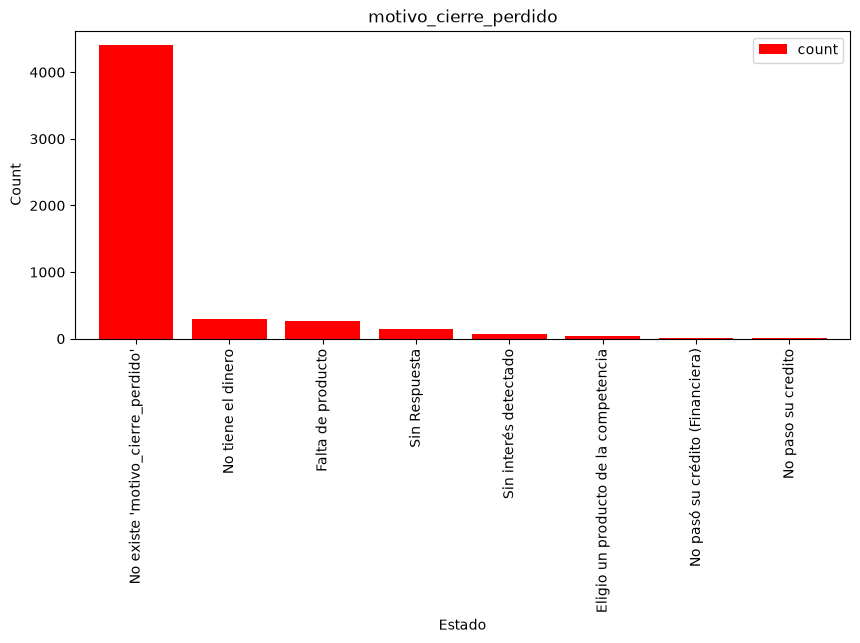

In [80]:
#Realizamos grafico de barras del dataframe filtrado
Filtro_index.plot(kind = 'bar', width=0.8, figsize=(10,4), color= "red")
plt.title('motivo_cierre_perdido')
plt.xlabel('Estado')
plt.ylabel('Count')

In [ ]:
#Realizamos grafico de área del dataframe filtrado
Filtro_index.plot(kind='area', figsize=(10,4),alpha = 1, )

<Axes: >

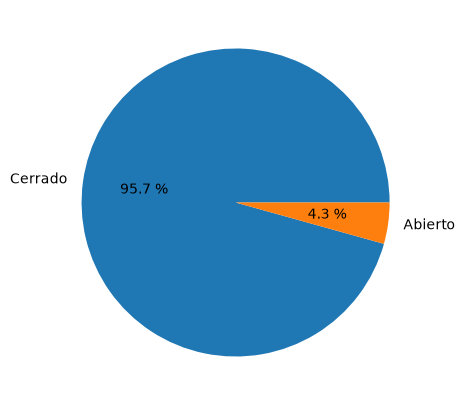

In [73]:
#Realizamos grafico de pastel del dataframe filtrado
Filtro_index["count"].plot(kind='pie', figsize=(10,5), shadow=False, autopct="%0.1f %%")

**Determinación de Clases para datos agrupados**


In [ ]:
# Ajustar maximo de filas
pd.options.display.max_rows = None

In [ ]:
#Corroboramos valores nulos
valores_nulos=Micro_Retailer.isnull().sum()
valores_nulos

In [ ]:
#Calculamos el numero total de la población "n"
Micro_Retailer['fecha'].info()
n=43751

In [ ]:
#Obtenemos el limite superior y el límite inferior de la columna objetivo
Max=Micro_Retailer['fecha'].max()
Min=Micro_Retailer['fecha'].min()
Limites= [Min, Max]
Limites

In [ ]:
#Calculamos el rango R
R=Max-Min
R

In [ ]:
#Calculamos el número de Intervalos de Clase "ni", aplicando la regla de Sturges
ni= 1+3.32*np.log10(n)
ni

In [ ]:
#Calculamos el Ancho del Intervalo "i"
i=R/ni
i

**Creación de Categorias a partir de clases**

In [ ]:
#Categorización de variables
#Declaramos 8 intervalos 
#Ajustamos los limites para que todos los valores sean incluidos en los intervalos
#Ampliamos los límites en una unidad sobre los decimales menos significativos
#con la intención de incluir los valores que caigan justo en los límites
#np.float64(18.9993095), np.float64(19.0752733)
intervalos=np.linspace(3.7, 767, 9)
intervalos

In [ ]:
#Creamos las categorías 
categorias= ["Extremadamente Bajo(3.7 - 99.11)", "Muy Bajo(99.11 - 194.52)","Bajo(194.52 - 289.93)", "Precio normal(289.93 - 385.35)", "Alto(385.35 - 480.76)", "Muy Alto(480.76 - 576.17)","Extremadamente Alto(576.17 - 671.58)", "Premium(671.58 - 767)"]

In [ ]:
#Finalmente creamos las categorías en la columna numérica
Micro_Retailer['price_quote_price_per_night']=pd.cut(x= Micro_Retailer['price_quote_price_per_night'], bins=intervalos, labels= categorias)
Micro_Retailer['price_quote_price_per_night']

In [ ]:
#Obtengo un análisis univariado de las variables categóricas
Tabla_freq = Micro_Retailer['price_quote_price_per_night'].value_counts().reset_index()
Tabla_freq

In [ ]:
#Obtengo un filtro de los valores más relevantes de la variable categórica seleccionada
Filtro= Tabla_freq[Tabla_freq['count']>0]
Filtro

In [ ]:
#Ajusto el indice de mi dataframe
Filtro_index= Filtro.set_index('price_quote_price_per_night')
Filtro_index

In [ ]:
#Realizamos grafico de barras del dataframe filtrado
Filtro_index.plot(kind = 'bar', width=0.8, figsize=(10,4), color= "red", rot=45)
plt.title('price_quote_price_per_night')
plt.xlabel('Rangos de precio')
plt.ylabel('Conteo')